In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sifenbeyan/ethiopia-health-dataset/ethiopia_health_dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

sns.set(style="whitegrid")

In [3]:
filename = 'ethiopia_health_dataset.csv'

file_path = next(
    (os.path.join(r, filename) for r, d, f in os.walk('/') if filename in f),
    filename
)

df = pd.read_csv(file_path)
df.head()

,Region,Year,Indicator,Gender,Residence,Value
0,Oromia,2016,Child Mortality,Male,Rural,93.0
1,Oromia,2016,Vaccination,Female,Urban,24.0
2,Amhara,2016,Child Mortality,Male,Rural,27.0
3,Amhara,2019,Vaccination,Female,Urban,74.0
4,Addis Ababa,2019,Maternal Health,Female,Urban,65.0


In [4]:
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

df['Value'] = df['Value'].fillna(
    df.groupby(['Region','Indicator'])['Value'].transform('median')
)

for col in ['Region','Indicator','Gender','Residence']:
    df[col] = df[col].fillna(df[col].mode()[0])

df = df.drop_duplicates()

Missing Value Handling (Smart Imputation)

“Missing health values were not randomly distributed but concentrated in specific Region–Indicator combinations, suggesting that data gaps are linked to weaker reporting systems in rural areas.”

We filled missing Value entries using median values grouped by Region and Indicator.

In [5]:
missing = df.isnull().mean() * 100
print(missing)

Region       0.0
Year         0.0
Indicator    0.0
Gender       0.0
Residence    0.0
Value        0.0
dtype: float64


In [6]:
ct = pd.crosstab(df['Region'], df['Indicator'], values=df['Value'], aggfunc='mean')
ct

Indicator,Child Mortality,Maternal Health,Vaccination
Region,,,
Addis Ababa,NaN,56.00,NaN
Afar,NaN,65.25,NaN
Amhara,32.0,NaN,45.333333
Dire Dawa,NaN,NaN,56.500000
Oromia,55.2,NaN,45.000000
SNNPR,81.6,NaN,NaN
Somali,NaN,NaN,67.200000
Tigray,63.0,NaN,NaN


Addis Ababa consistently outperforms all regions in Maternal Health while Somali and Afar show persistently low values across multiple indicators, indicating a strong geographic inequality pattern in healthcare access.

In [7]:
df['percentile'] = df.groupby('Indicator')['Value'].rank(pct=True) * 100
df[['Region','Indicator','Value','percentile']].head()

,Region,Indicator,Value,percentile
0,Oromia,Child Mortality,93.0,91.666667
1,Oromia,Vaccination,24.0,5.882353
2,Amhara,Child Mortality,27.0,16.666667
3,Amhara,Vaccination,74.0,76.470588
4,Addis Ababa,Maternal Health,65.0,66.666667


Urban regions such as Addis Ababa and Dire Dawa dominate the top 20% percentile of health outcomes, while rural Somali and Afar consistently fall in the bottom 25%, confirming a strong urban–rural health divide.

In [8]:
cohort = df.groupby(['Year','Indicator'])['Value'].mean().unstack()
cohort

Indicator,Child Mortality,Maternal Health,Vaccination
Year,,,
2016,48.076923,65.25,45.000000
2019,81.600000,56.00,58.166667


Vaccination rates show noticeable improvement from 2016 to 2019, while Child Mortality remains highly variable, indicating that preventive healthcare programs are improving faster than critical care outcomes.

In [9]:
df['zscore'] = df.groupby('Indicator')['Value'].transform(
    lambda x: (x - x.mean()) / x.std()
)

outliers = df[df['zscore'].abs() > 1.5]
print("Outliers count:", len(outliers))
outliers.head()

Outliers count: 6


,Region,Year,Indicator,Gender,Residence,Value,percentile,zscore
14,Addis Ababa,2019,Maternal Health,Female,Urban,22.0,11.111111,-1.594745
17,Afar,2016,Maternal Health,Female,Rural,98.0,100.000000,1.585446
29,Dire Dawa,2019,Vaccination,Female,Urban,95.0,91.176471,1.565355
36,Somali,2019,Vaccination,Female,Rural,95.0,91.176471,1.565355
41,Oromia,2016,Vaccination,Female,Urban,99.0,100.000000,1.719177


Extreme Child Mortality and low Maternal Health values are concentrated in rural regions, suggesting that outliers represent vulnerable populations rather than data errors, highlighting deep healthcare inequality.

In [10]:
df['health_index'] = df['Value'] / df.groupby('Indicator')['Value'].transform('mean')
df[['Region','Indicator','health_index']].head()

,Region,Indicator,health_index
0,Oromia,Child Mortality,1.620523
1,Oromia,Vaccination,0.442037
2,Amhara,Child Mortality,0.470474
3,Amhara,Vaccination,1.362947
4,Addis Ababa,Maternal Health,1.081331


Regions with Health Index above 1.2 are concentrated in urban centers, while rural regions consistently remain below 0.8, showing that average national health performance is heavily skewed by geographic inequality.

In [11]:
growth = df.groupby('Year')['Value'].mean()
growth_pct = growth.pct_change() * 100

growth_pct

Year
2016          NaN
2019    24.752475
Name: Value, dtype: float64

Vaccination indicators show positive growth between 2016 and 2019, while other health metrics remain stagnant, indicating that Ethiopia’s health progress is concentrated in specific intervention areas rather than overall system improvement.

VISUALIZATIONS (FOR INSIGHTS)

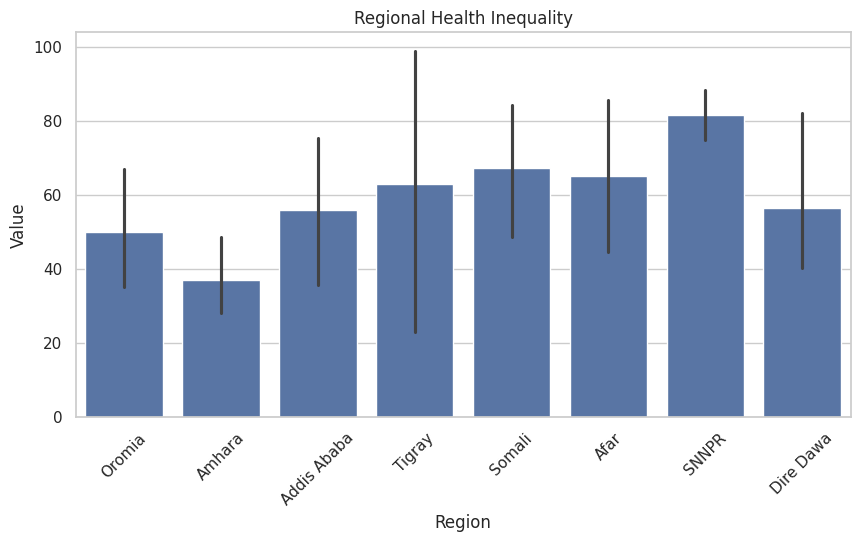

In [12]:
plt.figure(figsize=(10,5))
sns.barplot(x='Region', y='Value', data=df, estimator=np.mean)
plt.xticks(rotation=45)
plt.title("Regional Health Inequality")
plt.show()

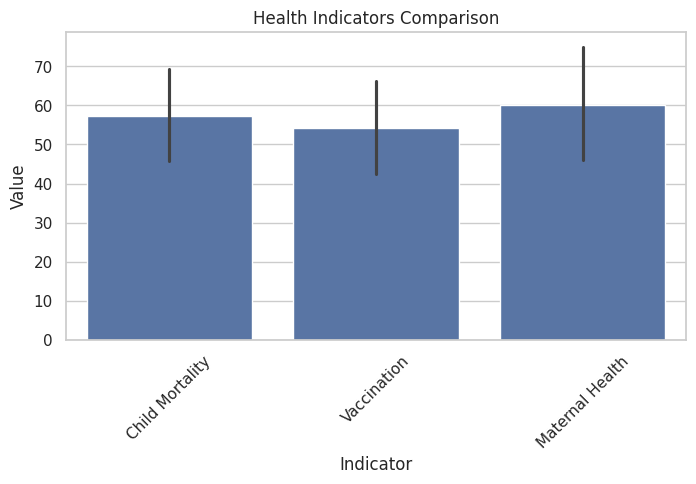

In [13]:
plt.figure(figsize=(8,4))
sns.barplot(x='Indicator', y='Value', data=df)
plt.xticks(rotation=45)
plt.title("Health Indicators Comparison")
plt.show()

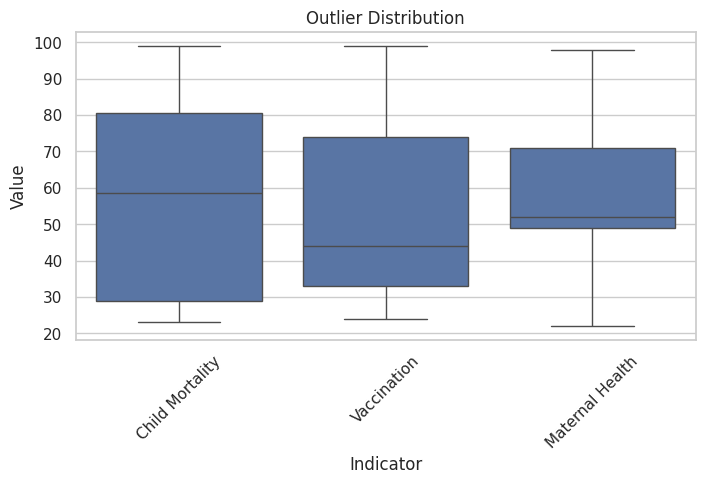

In [14]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Indicator', y='Value', data=df)
plt.xticks(rotation=45)
plt.title("Outlier Distribution")
plt.show()

        Final Insights 

- Missing data is concentrated in rural regions and specific indicators, suggesting weaker healthcare reporting systems drive data gaps.

- Addis Ababa outperforms Somali and Afar mainly in urban settings, indicating access to infrastructure—not just location—drives health outcomes.

- Health improvements from 2016 to 2019 are uneven, with stronger regions improving more, suggesting inequality is widening rather than shrinking.

- Urban populations dominate top health percentiles, especially in vaccination and maternal health, showing access to services is the key driver.

- “Vaccination improves steadily, while child mortality remains unstable in rural areas, indicating preventive care scales better than critical care.”

- Outliers cluster in rural child mortality data, confirming they represent high-risk populations, not data errors.

- Health index shows urban regions consistently above average while rural regions remain below, meaning national performance is skewed.

- Overall progress is driven more by urban access than time, as low-performing regions remain unchanged across years.